# 🧠 1. Introduction

In this notebook, we will explore how **Linear Regression** can be used in **cybersecurity** to analyze and predict system behavior.  

Linear Regression helps us model relationships between variables and predict future values.  
In cybersecurity, this can be applied to detect **abnormal patterns** that may indicate an attack or performance issue.

We will focus on **two examples**:
1. Predicting CPU usage to detect abnormal spikes.  
2. Estimating attack duration from past data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


# ⚙️ 3. Case 1: Predicting CPU Usage to Detect Abnormal Spikes

## 🔹 Idea

Imagine a security monitoring system that collects the CPU usage of a server every hour.  
We can use Linear Regression to predict **normal CPU usage trends**  and detect if an observed spike is **abnormal**, which may indicate a **DDoS attack** or **malware** consuming resources.


## 🔹 Step 1: Generate Simulated Data

We create simple sample data representing the CPU usage over time under normal conditions.


In [2]:
# Hours (time)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1)

# Normal CPU usage pattern
y = np.array([20, 25, 28, 30, 35, 38, 40, 42, 45, 47])  # normal increase


In [3]:
model = LinearRegression()
model.fit(X, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 🔹 Step 3: Make Predictions + Add an Attack Spike

After training, we predict CPU usage for the next few hours.  
We also simulate a sudden **attack spike** to visualize the difference between predicted and real abnormal usage.


In [4]:
X_future = np.array([[11], [12], [13]])
y_pred = model.predict(X_future)

# Simulate a sudden attack spike
attack_value = 85  # observed real CPU usage (too high)


## 🔹 Step 4: Visualization

We will plot:
- Blue dots → historical CPU usage (normal).  
- Green line → predicted trend.  
- Orange dots → future predicted values.  
- Red dot → simulated attack spike (anomaly).


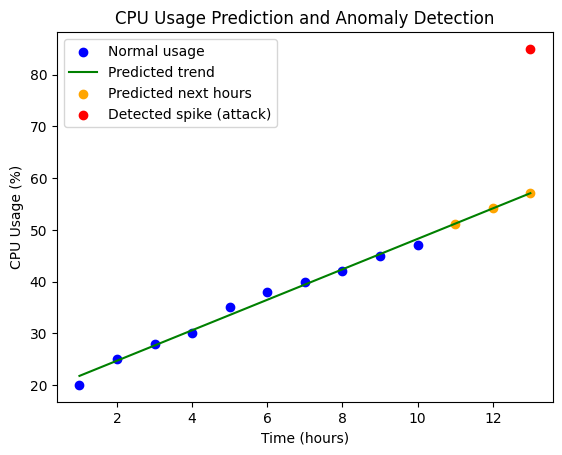

In [5]:
plt.scatter(X, y, color='blue', label="Normal usage")
plt.plot(np.vstack((X, X_future)), model.predict(np.vstack((X, X_future))), color='green', label="Predicted trend")
plt.scatter(X_future, y_pred, color='orange', label="Predicted next hours")
plt.scatter([13], [attack_value], color='red', label="Detected spike (attack)")
plt.xlabel("Time (hours)")
plt.ylabel("CPU Usage (%)")
plt.title("CPU Usage Prediction and Anomaly Detection")
plt.legend()
plt.show()


## 🔹 Step 5: Interpretation

If the **observed CPU usage** (red point) is **much higher** than the predicted value,  
it could indicate an **anomaly**  for example, a **DDoS attack**, **crypto-mining malware**, or **unauthorized process**.
